<a href="https://cognitiveclass.ai"><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0101EN-SkillsNetwork/images/IDSN-logo.png" width="400"> </a>

# BackPropagation

Estimated time needed: **30** mins


Backpropagation is the key algorithm used for training neural networks, allowing them to learn from data. It is based on the gradient descent optimization technique and works by iteratively adjusting the weights and biases of the network to minimize the error between the predicted and actual outputs.
 In this lab, we will create a neural network to implement backpropagation for a XOR problem.
역전파는 신경망을 훈련하는 데 사용되는 핵심 알고리즘으로, 신경망이 데이터를 통해 학습할 수 있도록 합니다. 이는 경사 하강 최적화 기법을 기반으로 하며, 예측값과 실제값 사이의 오차를 최소화하기 위해 신경망의 가중치와 편향을 반복적으로 조정하는 방식으로 작동합니다.
이번 실습에서는 XOR 문제에 대한 역전파를 구현하는 신경망을 생성합니다.

# Objective for this notebook

* Train a Neural Network to Solve the XOR Problem
* Implement Backpropagation for Neural Network Training
* Demonstrate the Use of Activation Functions
* Understand the Learning Process Over Multiple Epochs
* Demonstrate Weight and Bias Adjustments via Gradient Descent
* Evaluate the Model's Performance After Training
* Monitor and Analyze the Training Process

# Objective for this notebook

* Train a Neural Network to Solve the XOR Problem
* Implement Backpropagation for Neural Network Training
* Demonstrate the Use of Activation Functions
* Understand the Learning Process Over Multiple Epochs
* Demonstrate Weight and Bias Adjustments via Gradient Descent
* Evaluate the Model's Performance After Training
* Monitor and Analyze the Training Process

# 이 노트북의 목표

* XOR 연산을 수행하는 신경망 학습
* 신경망 학습을 위한 역전파 구현
* 활성화 함수의 사용법 시연
* 여러 에포크에 걸친 학습 과정 이해
* 경사 하강법을 이용한 가중치 및 편향 조정 시연
* 학습 후 모델 성능 평가
* 학습 과정 모니터링 및 분석


<h2>Table of Contents</h2>


<div class="alert alert-block alert-info" style="margin-top: 20px">

<font size = 4>
1. <a href="#Import-Required-Libraries">Import Required Libraries</a><br>
2. <a href="#Initialize-Inputs">Initialize Inputs</a><br>
3. <a href="#Declare-the-network-parameters">Declare the network parameters</a><br>
4. <a href="#Define-the-weights">Define the weights</a><br>  
5. <a href="#Training-the-Neural-Network">Training the Neural Network</a><br>  
6. <a href="#Testing-the-Network">Testing the Network</a><br>  
7. <a href="#Plot-the-error">Plot the error</a><br>  

</font>
</div>


In [21]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented. 
# If you run this notebook on a different environment, e.g., your desktop, you may need to uncomment and install certain libraries.

#!pip install numpy==1.26.4
#!pip install matplotlib==3.5.2

## Import Required Libraries
## 필수 라이브러리 가져오기

In [22]:
# Importing the required library
import numpy as np
import matplotlib.pyplot as plt

## Initialize Inputs
Define the input and expected output for a XOR gate problem


In [23]:
# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 1, 1, 0])  # Expected output for XOR

# Declare the network parameters & the weights

Define the network parameters such as
1. number of input neurons
2. hidden layer neurons
3. output neurons
4. learning rate
5. number of epochs

Also, Declare the weights for the neurons. The initial weights are taken as random numbers which are then optimized by the backpropagation algorithm inside a function parameter `initialize_network_parameters()`

# 네트워크 파라미터 및 가중치 선언

다음과 같은 네트워크 파라미터를 정의합니다.
1. 입력 뉴런 수
2. 은닉층 뉴런 수
3. 출력 뉴런 수
4. 학습률
5. 에포크 수

또한, 뉴런의 가중치를 선언합니다. 초기 가중치는 난수로 설정되며, `initialize_network_parameters()` 함수 내에서 역전파 알고리즘을 통해 최적화됩니다.

In [24]:
# 네트워스 아키텍처
def initialize_network_parameters():
    # Network parameters
    inputSize = 2      # 입력층 2개
    hiddenSize = 2     # 은닉층 2개
    outputSize = 1     # 출력층 한개
    lr = 0.1           # 학습률
    epochs = 180000    # 전체 데이터셋을 180,000번 반복 학습

    # Initialize weights and biases randomly within the range [-1, 1]
    # 가중치 초기화
    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1  # (2x2 행렬, 0~1 사이 랜덤 값) * 2 - 1
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1          # Bias for hidden layer
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # Weights from hidden to output layer
    b2 = np.random.rand(outputSize, 1) * 2 - 1          # Bias for output layer

    return w1, b1, w2, b2, lr, epochs


## Training the Neural Network


The neural network works in 5 stages:


1. Forward pass
    * The input **X** is multiplied by the weights **w1** and passed through the first layer, followed by the application of the sigmoid or ReLU activation function. This gives the output for the hidden layer.
    * The output of the hidden layer is then passed through the second set of weights **w2** to compute the final output. Again, a sigmoid activation function is used to generate the final output **a2**.
    
2. Error calculation
    * The error is computed as the difference between the expected output **(d)** and the actual output **(a2)**.
3. Backward pass
    * **Output Layer**: The derivative of the sigmoid activation function is applied to the error, producing the gradient for the output layer **(da2)**. This is used to calculate how much the weights in the output layer need to be adjusted.
    * **Hidden Layer**: The error is then propagated backward to the hidden layer. The gradient at the hidden layer **(da1)** is computed by taking the dot product of the transpose of the weights **(w2.T)** and the gradient from the output layer. The derivative of the activation function (sigmoid or ReLU) is used to adjust this error.
4. Weights and bias updates
    * After computing the **gradients (dz1, dz2)**, the **weights (w1, w2)** and **biases (b1, b2)** are updated using the **learning rate (lr)** and **the gradients**. The updates are done to minimize the error and improve the model’s predictions.
5. Training:
    * This entire process is repeated over many iterations **(epochs)**. During each epoch, the model adjusts its weights and biases to reduce the error. Over time, the network learns to approximate the XOR function.

## 신경망 훈련
신경망은 다음 5단계로 작동합니다.
1. 순방향 전달
    * 입력 **X**는 가중치 **w1**과 곱해져 첫 번째 은닉층을 통과한 후 시그모이드 또는 ReLU 활성화 함수를 적용받습니다. 이로써 은닉층의 출력이 생성됩니다.
    * 은닉층의 출력은 두 번째 가중치 **w2**를 통과하여 최종 출력을 계산합니다. 마찬가지로 시그모이드 활성화 함수를 사용하여 최종 출력 **a2**를 생성합니다.

2. 오차 계산
    * 오차는 예상 출력값 **(d)**과 실제 출력값 **(a2)**의 차이로 계산됩니다.

3. 역전파
    * **출력층**: 시그모이드 활성화 함수의 미분을 오차에 적용하여 출력층의 기울기 **(da2)**를 생성합니다. 이 기울기는 출력층의 가중치를 얼마나 조정해야 하는지 계산하는 데 사용됩니다.
    * **은닉층**: 오차는 은닉층으로 역전파됩니다. 은닉층의 기울기 **(da1)**은 가중치의 전치 행렬 **(w2.T)**과 출력층의 기울기의 내적을 계산하여 구합니다. 활성화 함수(시그모이드 또는 ReLU)의 미분을 사용하여 이 오차를 조정합니다

4. 가중치 및 편향 업데이트
    * **그래디언트(dz1, dz2)**를 계산한 후, **학습률(lr)**과 **그래디언트**를 사용하여 **가중치(w1, w2)**와 **편향(b1, b2)**을 업데이트합니다. 이러한 업데이트는 오류를 최소화하고 모델의 예측 정확도를 향상시키기 위해 수행됩니다.

5. 훈련:
    * 이 전체 과정은 여러 번의 **에포크(epoch)**에 걸쳐 반복됩니다. 각 에포크 동안 모델은 오류를 줄이기 위해 가중치와 편향을 조정합니다. 시간이 지남에 따라 네트워크는 XOR 함수를 근사화하는 방법을 학습합니다.

In [25]:
# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()
#np.dot(a,b) 함수는 a와 b의 배열을 서로 순차에 맞게 곱하여 더한 값
# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass 입력 → 예측
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation (오차 계산): 정답 - 예측
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer (역전파): 오차를 뒤로 전달
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases (가중치 업데이트): 오차 줄이는 방향으로
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


Epoch: 9999, Average error: 0.06723
Epoch: 19999, Average error: 0.03243
Epoch: 29999, Average error: 0.02407
Epoch: 39999, Average error: 0.01993
Epoch: 49999, Average error: 0.01735
Epoch: 59999, Average error: 0.01556
Epoch: 69999, Average error: 0.01422
Epoch: 79999, Average error: 0.01317
Epoch: 89999, Average error: 0.01232
Epoch: 99999, Average error: 0.01161
Epoch: 109999, Average error: 0.01101
Epoch: 119999, Average error: 0.01049
Epoch: 129999, Average error: 0.01004
Epoch: 139999, Average error: 0.00965
Epoch: 149999, Average error: 0.00929
Epoch: 159999, Average error: 0.00897
Epoch: 169999, Average error: 0.00868
Epoch: 179999, Average error: 0.00842


## Testing the Network
After training, you can now test the neural network to verify that it has learned the XOR function and outputs the correct values close to [0, 1, 1, 0]

## 네트워크 테스트
학습이 완료되면 신경망이 XOR 함수를 학습하고 [0, 1, 1, 0]에 가까운 올바른 값을 출력하는지 확인하기 위해 테스트할 수 있습니다.

In [26]:
# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))



Final output after training: [[0.00842475 0.99032734 0.9919891  0.00757811]]
Ground truth [0 1 1 0]
Error after training: [[-0.00842477  0.00967269  0.00801092 -0.00757813]]
Average error: 0.00842


## Plot the error
Here, we plot the error as a function of epochs. This shows how error changed over multiple iterations of forward and backward passes and how the network learnt over time


## 오류 그래프
여기서는 에포크 수에 따른 오류를 그래프로 나타냅니다. 이를 통해 순방향 및 역방향 패스의 여러 반복 과정에서 오류가 어떻게 변화했는지, 그리고 네트워크가 시간이 지남에 따라 어떻게 학습했는지를 확인할 수 있습니다.

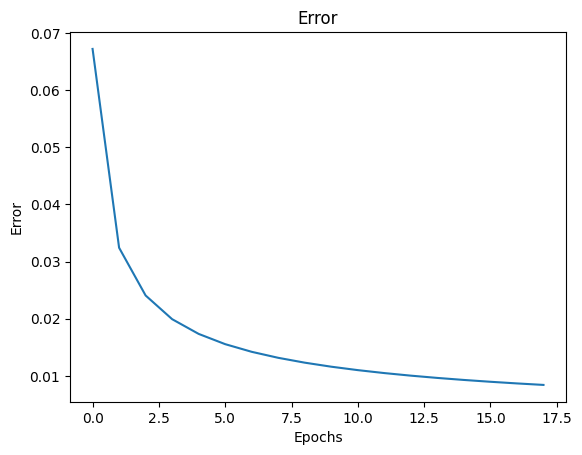

In [27]:
# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

# Practice exercise 1
# 연습문제 1

Implement backpropagation for **AND problem** using similar input as used for XOR problem above and plot the error

위의 XOR 문제에 사용된 것과 유사한 입력을 사용하여 **AND 문제**에 대한 역전파를 구현하고 오차를 그래프로 나타내십시오.

Epoch: 9999, Average error: 0.02199
Epoch: 19999, Average error: 0.01401
Epoch: 29999, Average error: 0.01096
Epoch: 39999, Average error: 0.00926
Epoch: 49999, Average error: 0.00814
Epoch: 59999, Average error: 0.00734
Epoch: 69999, Average error: 0.00673
Epoch: 79999, Average error: 0.00624
Epoch: 89999, Average error: 0.00584
Epoch: 99999, Average error: 0.00551
Epoch: 109999, Average error: 0.00523
Epoch: 119999, Average error: 0.00499
Epoch: 129999, Average error: 0.00477
Epoch: 139999, Average error: 0.00458
Epoch: 149999, Average error: 0.00441
Epoch: 159999, Average error: 0.00426
Epoch: 169999, Average error: 0.00412
Epoch: 179999, Average error: 0.00400

Final output after training: [[2.24953720e-04 4.59214061e-03 4.59127759e-03 9.93421092e-01]]
Ground truth [0 0 0 1]
Error after training: [[-0.00022495 -0.00459215 -0.00459129  0.00657893]]
Average error: 0.00400


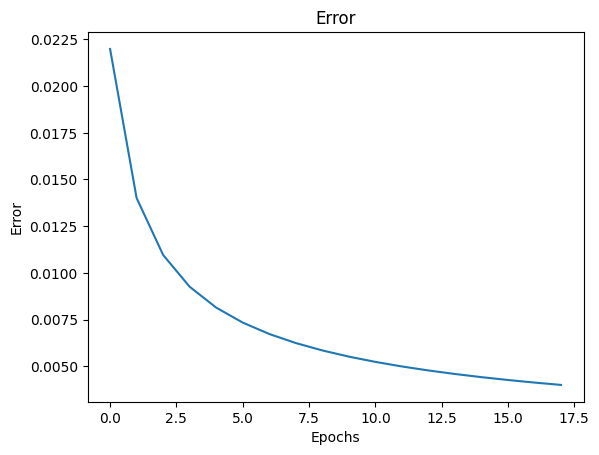

In [28]:
# Write your code here

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 0, 0, 1])  # Expected output for AND

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('\nFinal output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()



Double-click <b>here</b> for the solution.

<!-- Your answer is below:


X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 0, 0, 1])  # Expected output for AND

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('\nFinal output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()


-->


# Practice exercise 2


Now, decrease the learning rate to 0.01 and increase the number of epochs to 1000000 and check the error for XOR gate
이제 학습률을 0.01로 낮추고 에포크 수를 1,000,000으로 늘린 후 XOR 게이트의 오류를 확인해 보세요.


In [29]:
# Write your code here
# 네트워스 아키텍처
def initialize_network_parameters_exercise2():
    # Network parameters
    inputSize = 2      # 입력층 2개
    hiddenSize = 2     # 은닉층 2개
    outputSize = 1     # 출력층 한개
    lr = 0.01          # 학습률 #0.1로 변경
    epochs = 180000    # 전체 데이터셋을 180,000번 반복 학습

    # Initialize weights and biases randomly within the range [-1, 1]
    # 가중치 초기화
    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1  # (2x2 행렬, 0~1 사이 랜덤 값) * 2 - 1
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1          # Bias for hidden layer
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # Weights from hidden to output layer
    b2 = np.random.rand(outputSize, 1) * 2 - 1          # Bias for output layer

    return w1, b1, w2, b2, lr, epochs

Epoch: 9999, Average error: 0.28372
Epoch: 19999, Average error: 0.12605
Epoch: 29999, Average error: 0.07665
Epoch: 39999, Average error: 0.05679
Epoch: 49999, Average error: 0.04614
Epoch: 59999, Average error: 0.03943
Epoch: 69999, Average error: 0.03478
Epoch: 79999, Average error: 0.03134
Epoch: 89999, Average error: 0.02868
Epoch: 99999, Average error: 0.02655
Epoch: 109999, Average error: 0.02479
Epoch: 119999, Average error: 0.02332
Epoch: 129999, Average error: 0.02207
Epoch: 139999, Average error: 0.02098
Epoch: 149999, Average error: 0.02003
Epoch: 159999, Average error: 0.01919
Epoch: 169999, Average error: 0.01844
Epoch: 179999, Average error: 0.01776

Final output after training: [[6.91537932e-04 1.95800102e-02 1.76291605e-02 9.66847869e-01]]
Ground truth [0 0 0 1]
Error after training: [[-0.00069154 -0.01958008 -0.01762922  0.03315225]]
Average error: 0.01776


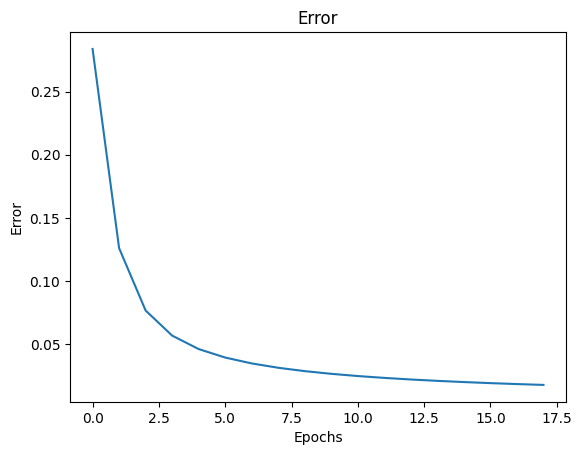

In [30]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 0, 0, 1])  # Expected output for AND

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters_exercise2()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('\nFinal output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

Double-click <b>here</b> for the solution.

<!-- Your answer is below:

lr = 0.01         # Learning rate
epochs = 1000000   # Number of training epochs


# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 1, 1, 0])  # Expected output for XOR

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))


# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('\nFinal output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))


# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()


-->


## Thank you for completing this lab!

This notebook was created by [Aman Aggarwal](https://www.linkedin.com/in/aggarwal-aman/). I hope you found this lab interesting and educational. Feel free to contact me if you have any questions!



<!--
## Change Log

|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2024-11-20  | 1.0  | Aman  |  Created the lab |
<hr>

## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>


## <h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
